# MULTI VARIATE EDA 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [6]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)
flower_Data=sns.load_dataset('iris')
flightdata=sns.load_dataset('flights')
tips=sns.load_dataset('tips')

In [9]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

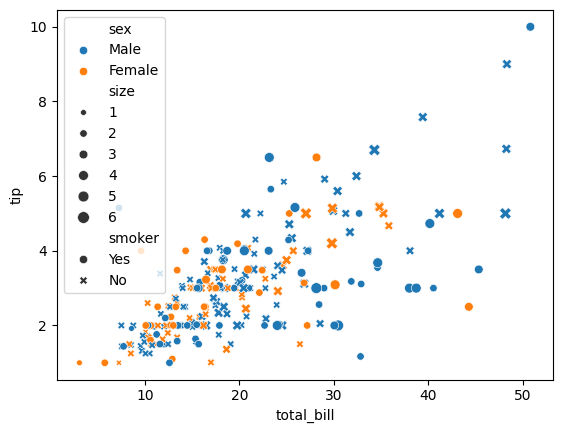

In [17]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'],style=tips['smoker'],size=tips['size'])

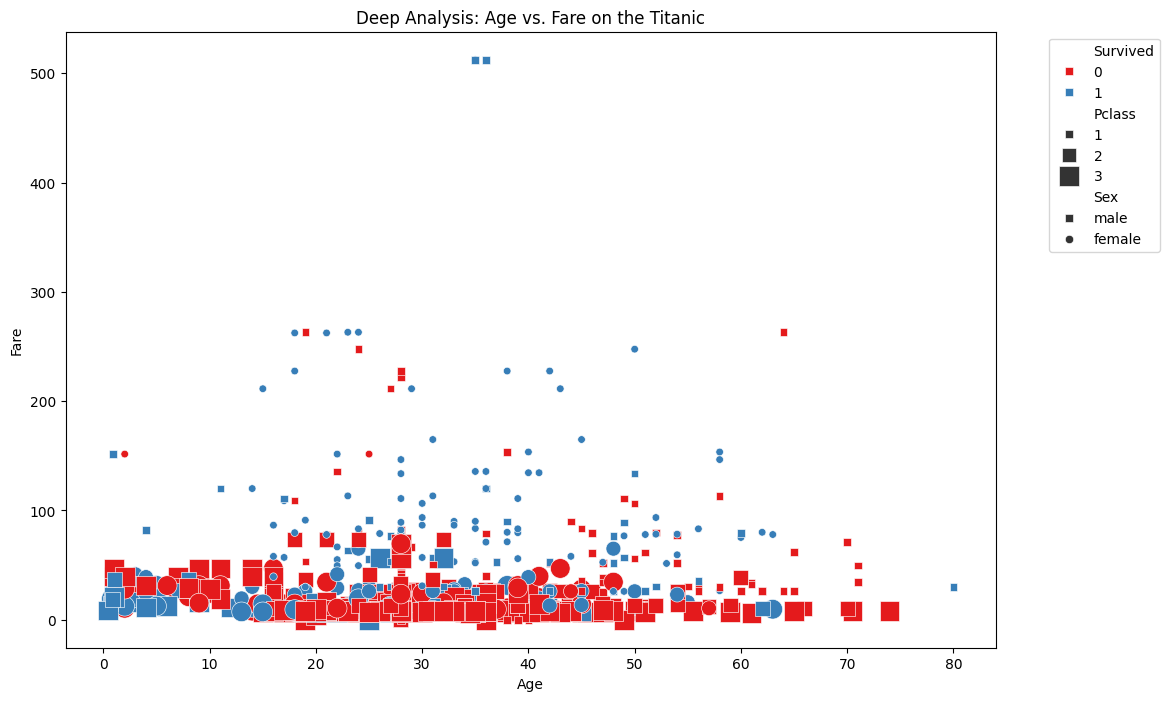

In [21]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

plt.figure(figsize=(12, 8))

# The Master Scatterplot
sns.scatterplot(
    data=titanic,            # 1. The Dataset
    x='Age',            # 2. X-axis (Continuous)
    y='Fare',           # 3. Y-axis (Continuous)
    hue='Survived',     # 4. Color coding (Categorical)
    style='Sex',        # 5. Marker shape (Categorical)
    size='Pclass',      # 6. Marker size (Continuous or Categorical)
    sizes=(30, 200),    # 7. Size range (Min size, Max size)
    alpha=1,          # 8. Transparency (0 to 1) - crucial for overlaps
    palette='Set1',     # 9. Color theme
    markers={'male': 's', 'female': 'o'}, # 10. Custom shapes (s=square, o=circle)
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Deep Analysis: Age vs. Fare on the Titanic')
plt.show()

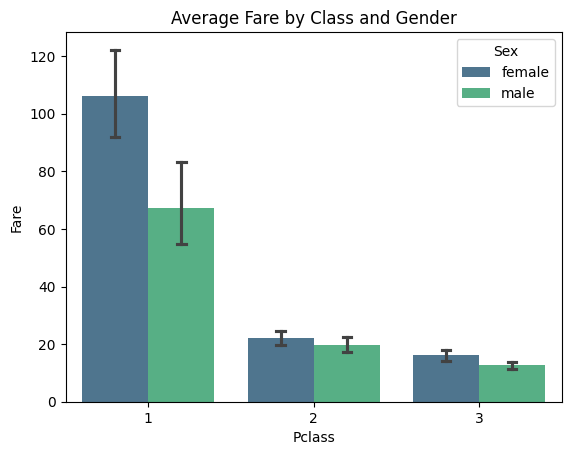

In [27]:
import  numpy as np

# The Master Bar Plot
sns.barplot(
    data=titanic,
    x='Pclass',          # 1. Categorical Axis
    y='Fare',            # 2. Numerical Axis (to be averaged)
    hue='Sex',           # 3. Sub-grouping (Color)
    estimator=np.mean,   # 4. Statistical function (default is mean)
    errorbar=('ci', 95), # 5. Confidence Interval (the "black line")
    palette='viridis',   # 6. Color theme
    order=[1,2,3],     # 7. Custom order of bars on X-axis
    capsize=0.1,         # 8. Width of the caps on error bars
    alpha=0.9,           # 9. Transparency
    orient='v'           # 10. Orientation ('v' for vertical, 'h' for horizontal)
)

plt.title('Average Fare by Class and Gender')
plt.show()

<Axes: xlabel='Sex', ylabel='Age'>

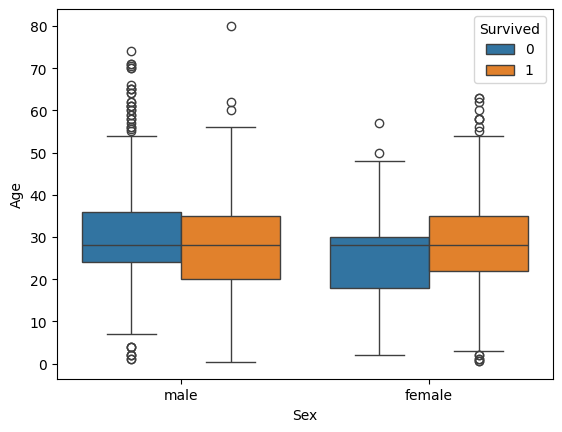

In [30]:
sns.boxplot(data=titanic,x=titanic['Sex'],y=titanic['Age'],hue=titanic['Survived'])

C:\Users\Malik\AppData\Local\Temp\ipykernel_24664\3942892072.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']==0]['Age'])
C:\Users\Malik\AppData\Local\Temp\ipykernel_24664\3942892072.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']==1

<Axes: xlabel='Age', ylabel='Density'>

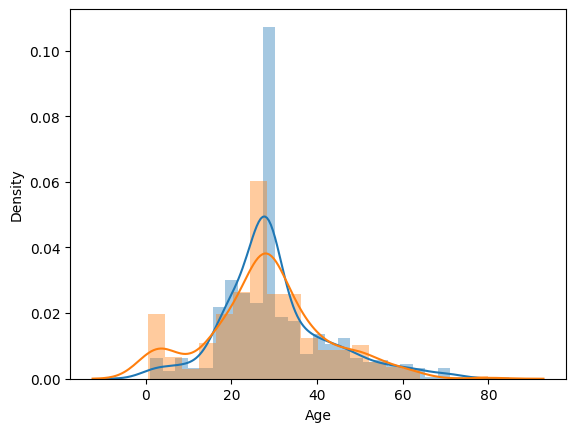

In [34]:
sns.distplot(titanic[titanic['Survived']==0]['Age'])
sns.distplot(titanic[titanic['Survived']==1]['Age'])


C:\Users\Malik\AppData\Local\Temp\ipykernel_24664\3138067409.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']==0]['Age'],hist=False)
C:\Users\Malik\AppData\Local\Temp\ipykernel_24664\3138067409.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t

<Axes: xlabel='Age', ylabel='Density'>

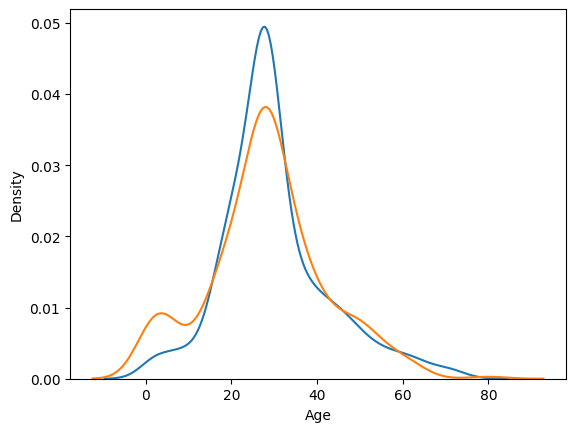

In [35]:
sns.distplot(titanic[titanic['Survived']==0]['Age'],hist=False)
sns.distplot(titanic[titanic['Survived']==1]['Age'],hist=False)


<Axes: xlabel='Survived', ylabel='Pclass'>

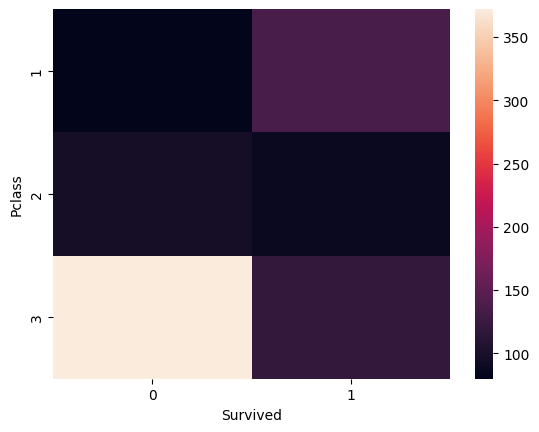

In [37]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic["Survived"]))

In [41]:
(titanic.groupby('Pclass').mean(numeric_only=True)['Survived'])

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: >

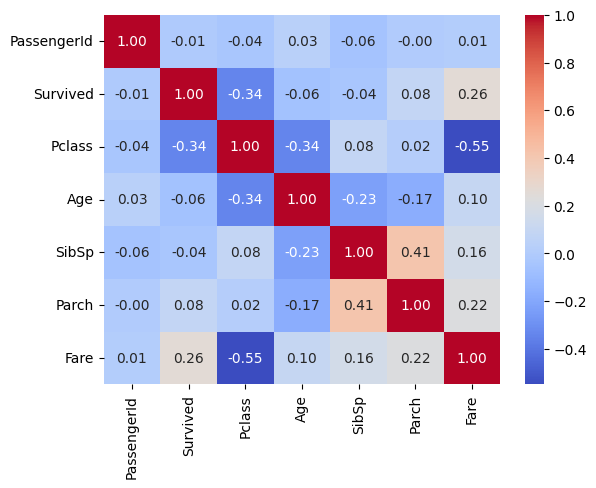

In [51]:
# over all heat map
numb_col=titanic.select_dtypes(include=['number'])

cor_mat=numb_col.corr()

sns.heatmap(data=cor_mat,annot=True, cmap='coolwarm', fmt=".2f")

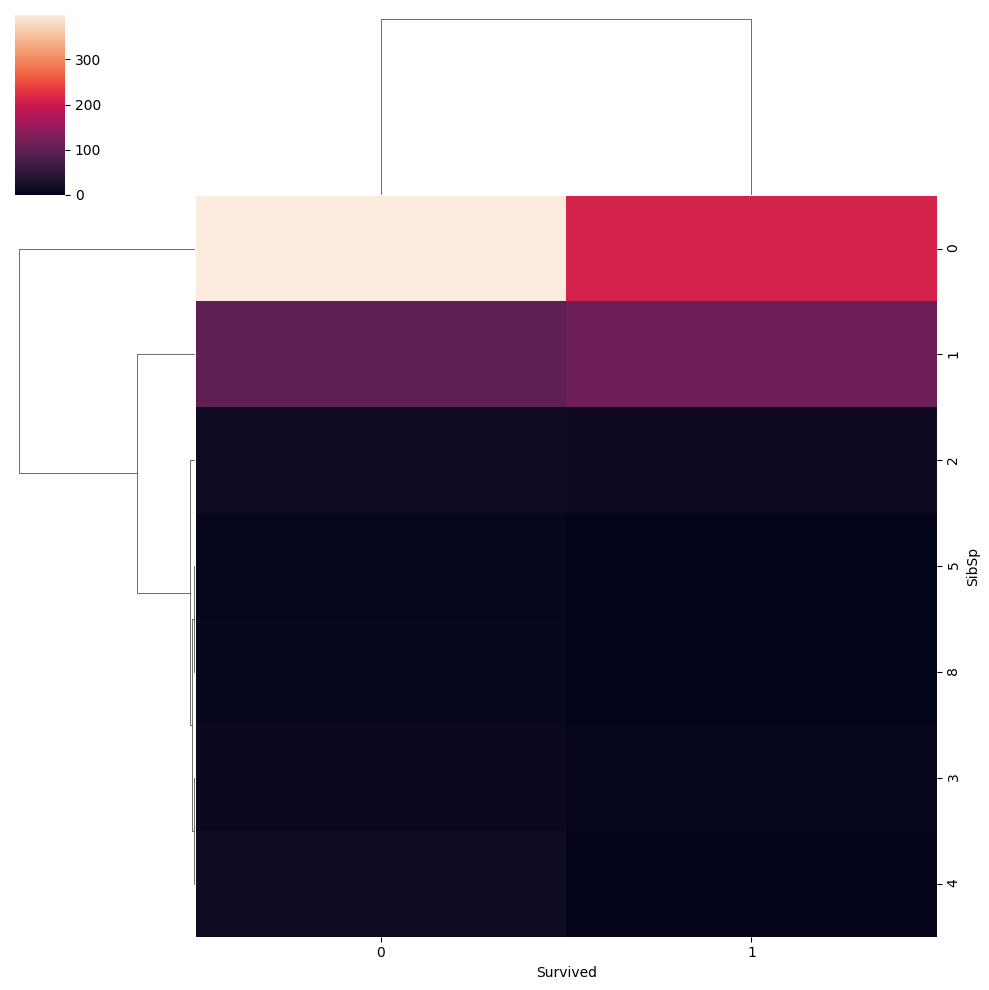

In [53]:
sns.clustermap(pd.crosstab(titanic['SibSp'],titanic['Survived']))

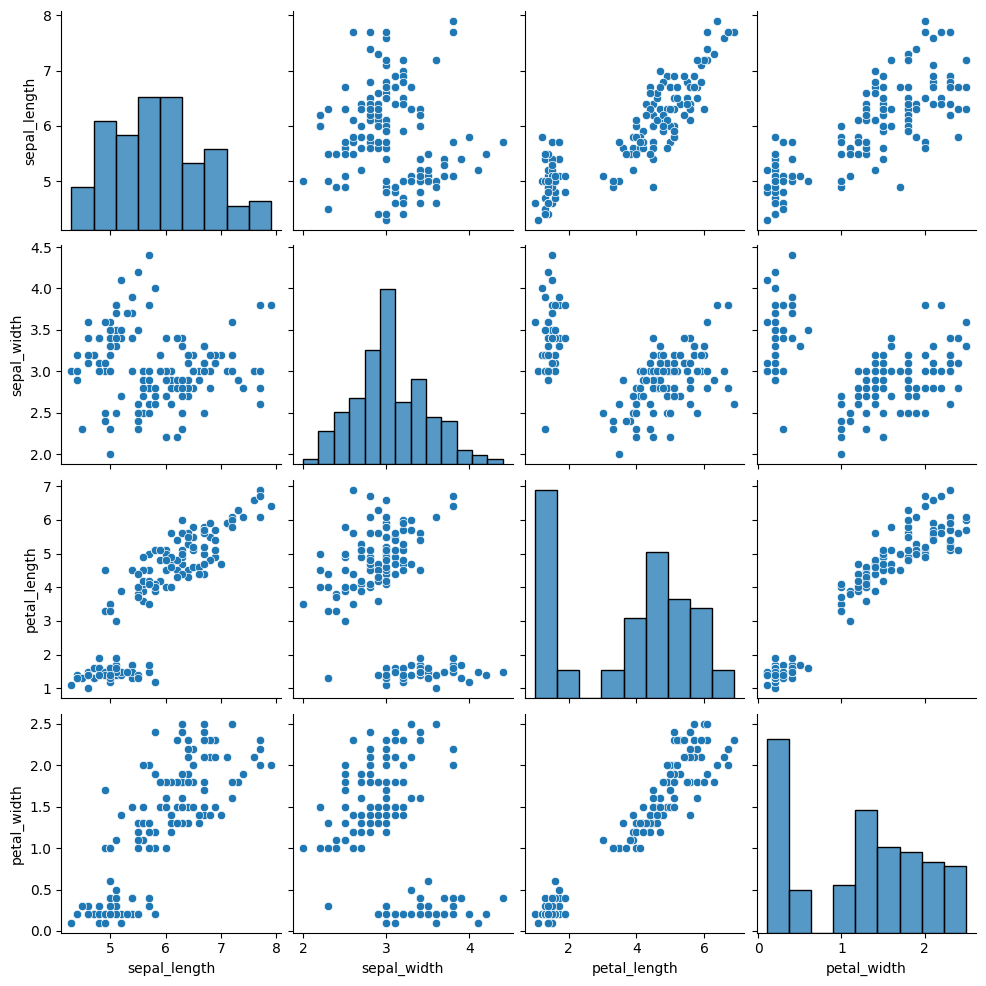

In [55]:
sns.pairplot(flower_Data)

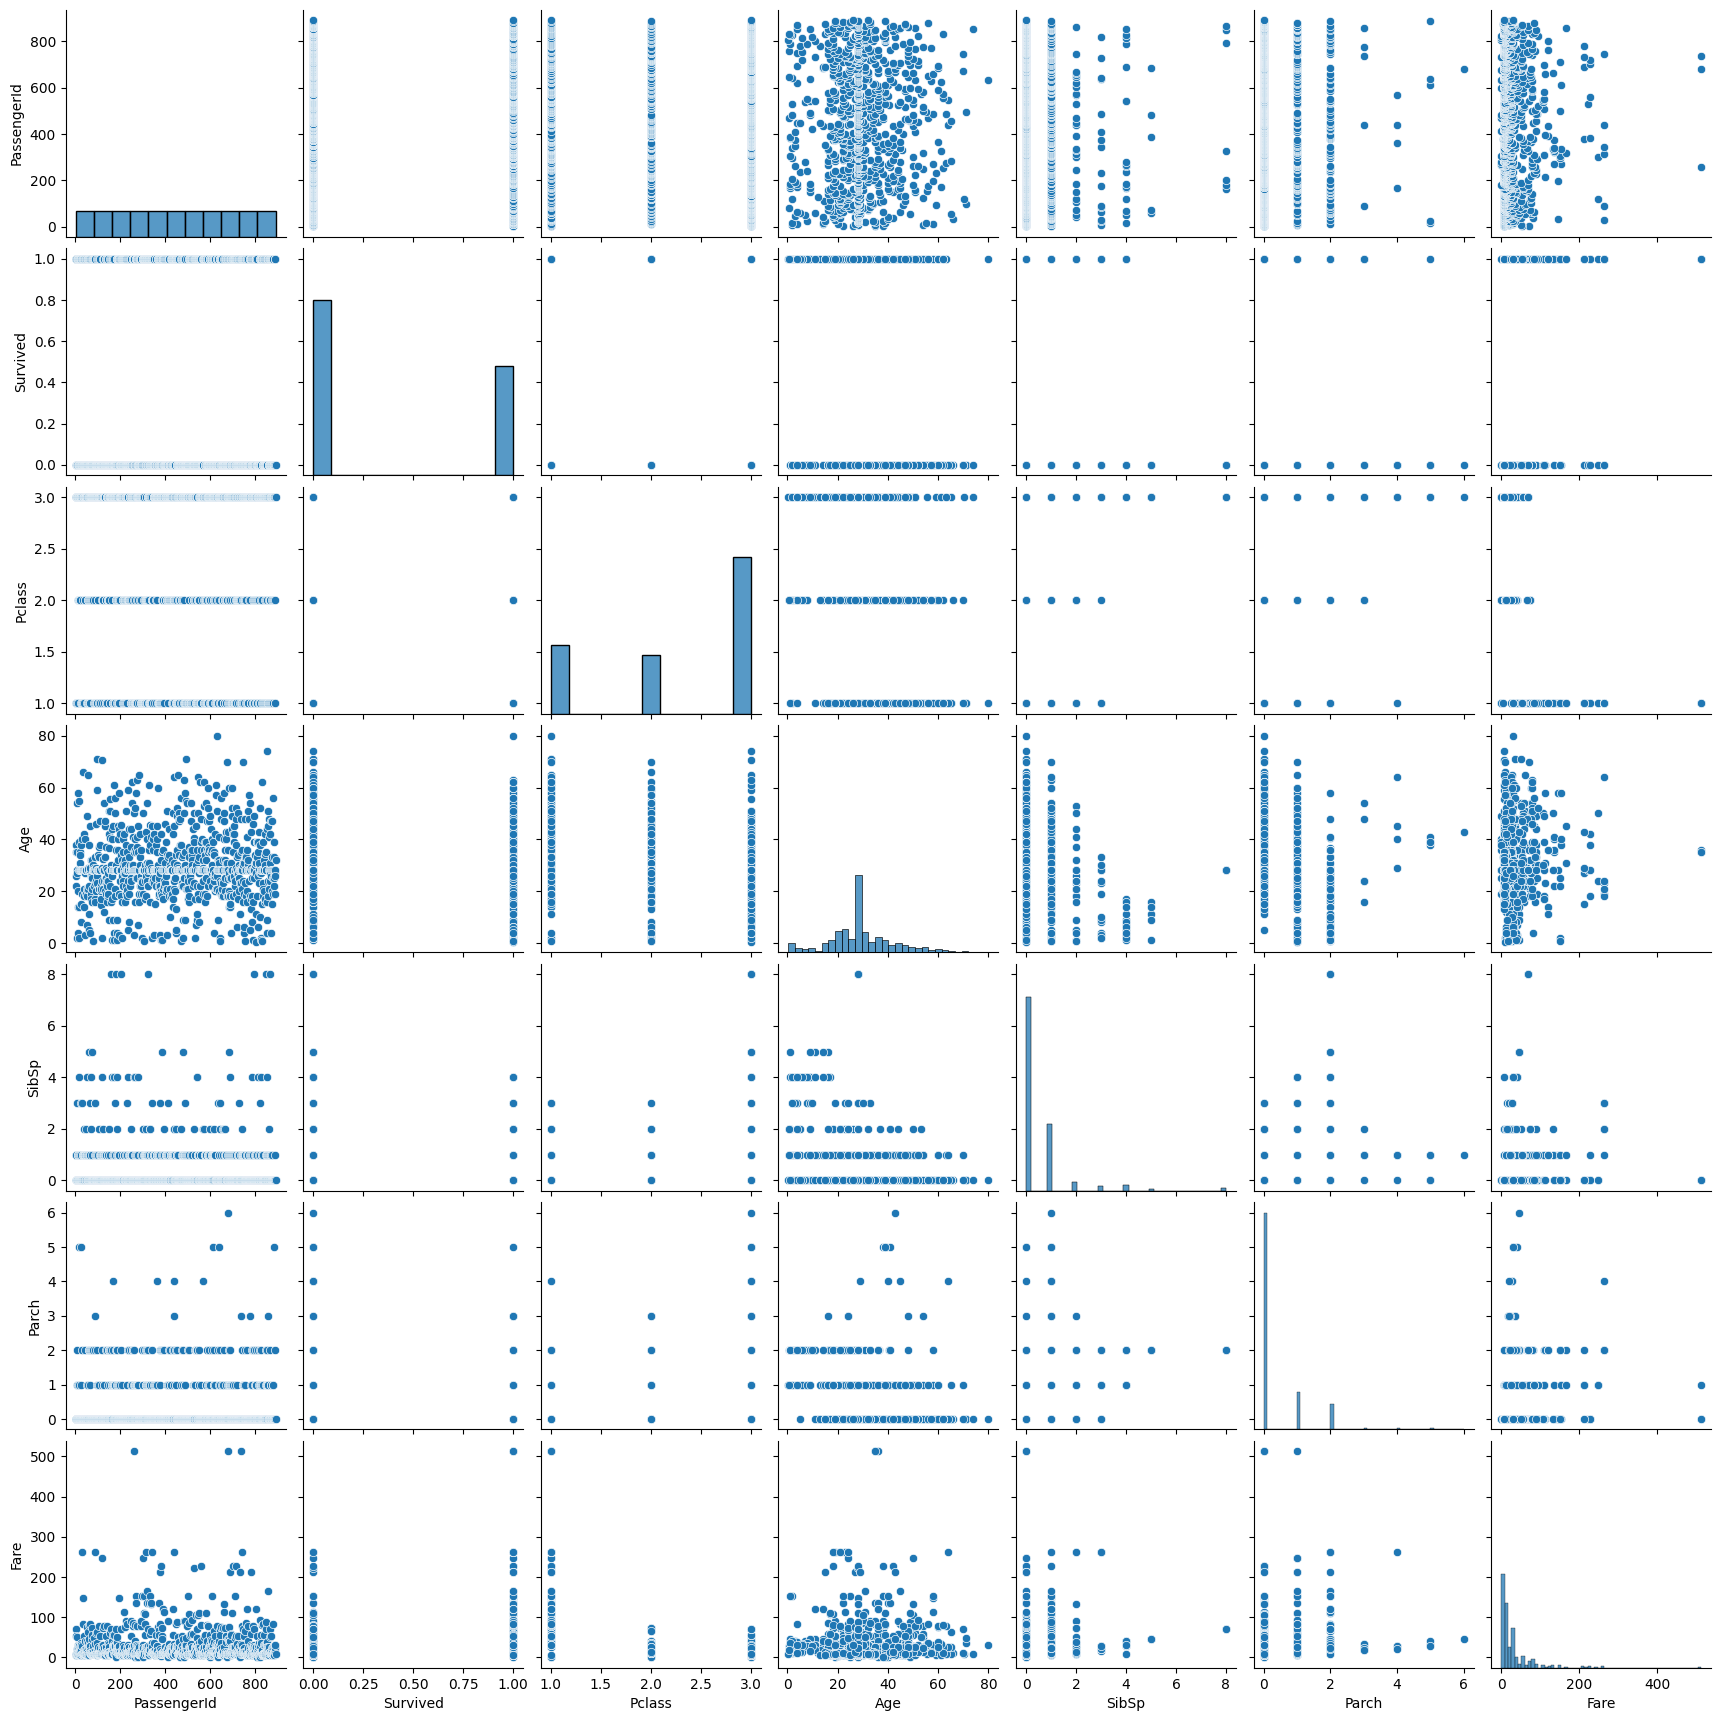

In [56]:
sns.pairplot(titanic)

In [61]:
#data=flightdata.groupby('year').sum().reset_index()
# Select the specific column you want to sum
data = flightdata.groupby('year')[['passengers']].sum().reset_index()

print(data.head())

   year  passengers
0  1949        1520
1  1950        1676
2  1951        2042
3  1952        2364
4  1953        2700


<Axes: xlabel='year', ylabel='passengers'>

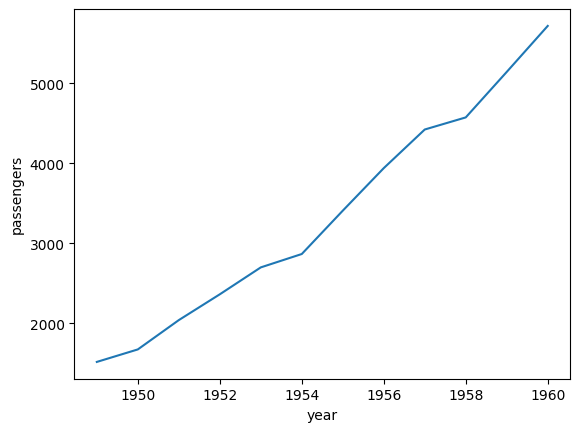

In [63]:
sns.lineplot(x=data["year"],y=data["passengers"])

<Axes: xlabel='year', ylabel='month'>

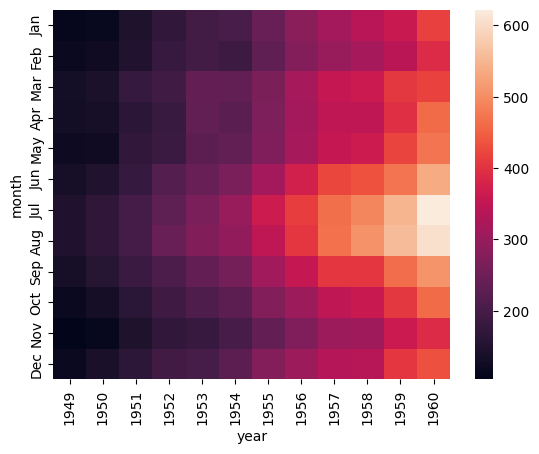

In [71]:
sns.heatmap(flightdata.pivot_table(values='passengers',index='month',columns='year'))